In [1]:
import os
import gc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [2]:
PROCESSED_PATH = "/kaggle/input/processed/processed"
VAE_PATH = "/kaggle/input/vae-model/vae"
OUTPUT_PATH = "/kaggle/working/vae_validation"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Load configuration
norm_constants = np.load(os.path.join(PROCESSED_PATH, 'norm_constants.npy'), allow_pickle=True).item()
metadata = np.load(os.path.join(PROCESSED_PATH, 'metadata.npy'), allow_pickle=True).item()

IMG_SIZE = norm_constants['img_size']
NUM_CHANNELS = len(norm_constants['room_types'])
ROOM_TYPES = norm_constants['room_types']

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Number of channels: {NUM_CHANNELS}")
print(f"Room types: {ROOM_TYPES}")

Image size: 256x256
Number of channels: 13
Room types: ['wall', 'bedroom', 'bathroom', 'living', 'kitchen', 'balcony', 'storage', 'parking', 'garden', 'pool', 'stair', 'veranda', 'inner']


In [3]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, channels)
        self.norm2 = nn.GroupNorm(8, channels)
    
    def forward(self, x):
        residual = x
        x = F.silu(self.norm1(self.conv1(x)))
        x = self.norm2(self.conv2(x))
        return F.silu(x + residual)


class Encoder(nn.Module):
    def __init__(self, in_channels, latent_dim, base_channels=64):
        super().__init__()
        self.conv_in = nn.Conv2d(in_channels, base_channels, 3, padding=1)
        
        self.down_blocks = nn.ModuleList([
            self._make_down_block(base_channels, base_channels * 2),
            self._make_down_block(base_channels * 2, base_channels * 4),
            self._make_down_block(base_channels * 4, base_channels * 8),
            self._make_down_block(base_channels * 8, base_channels * 8),
            self._make_down_block(base_channels * 8, base_channels * 8),
        ])
        
        self.conv_out = nn.Conv2d(base_channels * 8, base_channels * 8, 3, padding=1)
        self.norm_out = nn.GroupNorm(8, base_channels * 8)
        self.fc_mu = nn.Linear(base_channels * 8 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(base_channels * 8 * 8 * 8, latent_dim)
    
    def _make_down_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            ResidualBlock(out_ch),
        )
    
    def forward(self, x):
        x = F.silu(self.conv_in(x))
        for block in self.down_blocks:
            x = block(x)
        x = F.silu(self.norm_out(self.conv_out(x)))
        x = x.flatten(1)
        return self.fc_mu(x), self.fc_logvar(x)


class Decoder(nn.Module):
    def __init__(self, out_channels, latent_dim, base_channels=64):
        super().__init__()
        self.fc = nn.Linear(latent_dim, base_channels * 8 * 8 * 8)
        self.conv_in = nn.Conv2d(base_channels * 8, base_channels * 8, 3, padding=1)
        
        self.up_blocks = nn.ModuleList([
            self._make_up_block(base_channels * 8, base_channels * 8),
            self._make_up_block(base_channels * 8, base_channels * 8),
            self._make_up_block(base_channels * 8, base_channels * 4),
            self._make_up_block(base_channels * 4, base_channels * 2),
            self._make_up_block(base_channels * 2, base_channels),
        ])
        
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, out_channels, 3, padding=1),
            nn.Tanh()
        )
    
    def _make_up_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            ResidualBlock(out_ch),
        )
    
    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 512, 8, 8)
        x = F.silu(self.conv_in(x))
        for block in self.up_blocks:
            x = block(x)
        return self.conv_out(x)


class VAE(nn.Module):
    def __init__(self, in_channels, latent_dim, base_channels=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(in_channels, latent_dim, base_channels)
        self.decoder = Decoder(in_channels, latent_dim, base_channels)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar
    
    def encode(self, x):
        mu, logvar = self.encoder(x)
        return self.reparameterize(mu, logvar), mu, logvar
    
    def decode(self, z):
        return self.decoder(z)


# Load checkpoint
print("\nLoading VAE checkpoint...")
checkpoint_path = os.path.join(VAE_PATH, 'vae_best.pt')

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint not found at {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
VAE_CONFIG = checkpoint['config']
LATENT_DIM = VAE_CONFIG['latent_dim']

print(f"Checkpoint info:")
print(f"  Epoch: {checkpoint['epoch']}")
print(f"  Val loss: {checkpoint.get('val_loss', 'N/A')}")
print(f"  Latent dim: {LATENT_DIM}")

# Create and load model
vae = VAE(
    in_channels=NUM_CHANNELS,
    latent_dim=LATENT_DIM,
    base_channels=VAE_CONFIG['base_channels']
).to(DEVICE)

vae.load_state_dict(checkpoint['model_state_dict'])
vae.eval()

print("✓ VAE model loaded successfully")

# Count parameters
num_params = sum(p.numel() for p in vae.parameters())
print(f"Model parameters: {num_params:,}")


Loading VAE checkpoint...
Checkpoint info:
  Epoch: 0
  Val loss: 0.07216094775456135
  Latent dim: 256
✓ VAE model loaded successfully
Model parameters: 69,115,021


In [4]:
class FloorplanImageDataset(Dataset):
    """Dataset for loading preprocessed floorplan images."""
    
    def __init__(self, processed_path, max_samples=1000):
        self.processed_path = processed_path
        self.batch_dir = os.path.join(processed_path, 'batches')
        
        # Load metadata
        metadata = np.load(os.path.join(processed_path, 'metadata.npy'), allow_pickle=True).item()
        self.num_batches = metadata['num_batches']
        
        # Build index mapping
        self.samples = []
        
        for batch_idx in range(self.num_batches):
            batch_file = os.path.join(self.batch_dir, f'batch_{batch_idx:04d}.npz')
            if os.path.exists(batch_file):
                data = np.load(batch_file)
                num_samples = len(data['images'])
                data.close()
                
                for i in range(num_samples):
                    self.samples.append((batch_idx, i))
                    if len(self.samples) >= max_samples:
                        break
            
            if len(self.samples) >= max_samples:
                break
        
        # Cache for current batch
        self._cached_batch_idx = None
        self._cached_data = None
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        batch_idx, sample_idx = self.samples[idx]
        
        # Load batch if not cached
        if self._cached_batch_idx != batch_idx:
            if self._cached_data is not None:
                del self._cached_data
            
            batch_file = os.path.join(self.batch_dir, f'batch_{batch_idx:04d}.npz')
            self._cached_data = np.load(batch_file)
            self._cached_batch_idx = batch_idx
        
        # Get image
        image = self._cached_data['images'][sample_idx]
        
        # Convert to float and normalize to [-1, 1]
        image = image.astype(np.float32) / 255.0  # [0, 1]
        image = image * 2 - 1  # [-1, 1]
        
        return torch.from_numpy(image)


# Create validation dataset
print("\nCreating validation dataset...")
val_dataset = FloorplanImageDataset(PROCESSED_PATH, max_samples=1000)
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Validation samples: {len(val_dataset)}")
print(f"Validation batches: {len(val_loader)}")


Creating validation dataset...
Validation samples: 1000
Validation batches: 63



COMPUTING IoU PER CHANNEL


Computing IoUs: 100%|██████████| 63/63 [08:34<00:00,  8.17s/it]



Overall Mean IoU: 0.7912

Per-Channel IoU:
  wall        : 0.2708
  bedroom     : 0.8636
  bathroom    : 0.6470
  living      : 0.8654
  kitchen     : 0.7215
  balcony     : 0.2221
  storage     : 0.8960
  parking     : 0.9770
  garden      : 0.9710
  pool        : 1.0000
  stair       : 0.9500
  veranda     : 0.9590
  inner       : 0.9428


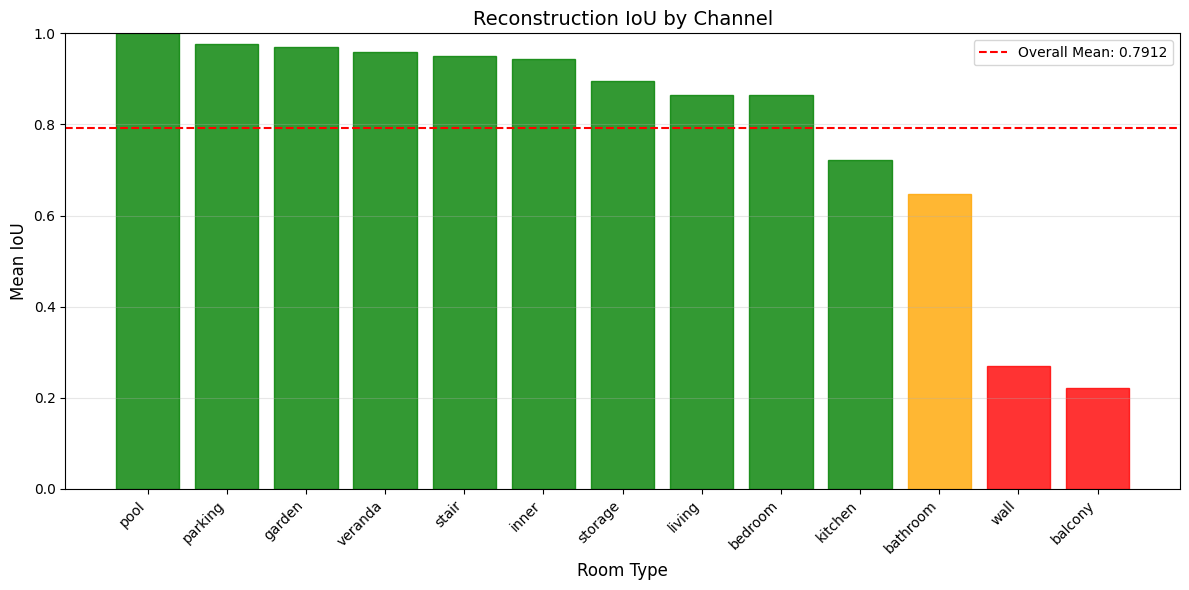

In [5]:
def compute_iou(pred, target, threshold=0.0):
    """
    Compute IoU between predicted and target masks.
    Both inputs should be in [-1, 1] range.
    """
    # Convert to binary masks
    pred_binary = (pred > threshold).float()
    target_binary = (target > threshold).float()
    
    # Compute intersection and union
    intersection = (pred_binary * target_binary).sum()
    union = pred_binary.sum() + target_binary.sum() - intersection
    
    # Handle empty masks
    if union < 1:
        return 1.0 if intersection < 1 else 0.0
    
    return (intersection / union).item()


def compute_channel_ious(vae, dataloader):
    """Compute IoU for each channel across the validation set."""
    channel_ious = defaultdict(list)
    
    vae.eval()
    with torch.no_grad():
        for images in tqdm(dataloader, desc="Computing IoUs"):
            images = images.to(DEVICE)
            
            # Get reconstructions
            recon, mu, logvar = vae(images)
            
            # Compute IoU for each channel and sample
            for i in range(images.shape[0]):
                for c in range(NUM_CHANNELS):
                    iou = compute_iou(recon[i, c], images[i, c])
                    channel_ious[c].append(iou)
    
    # Compute mean IoU per channel
    mean_ious = {}
    for channel_idx, ious in channel_ious.items():
        mean_ious[ROOM_TYPES[channel_idx]] = np.mean(ious)
    
    # Overall mean IoU
    overall_iou = np.mean([np.mean(ious) for ious in channel_ious.values()])
    
    return mean_ious, overall_iou, channel_ious


print("\n" + "="*60)
print("COMPUTING IoU PER CHANNEL")
print("="*60)

mean_ious, overall_iou, all_channel_ious = compute_channel_ious(vae, val_loader)

print(f"\nOverall Mean IoU: {overall_iou:.4f}")
print("\nPer-Channel IoU:")
for room_type in ROOM_TYPES:
    iou = mean_ious[room_type]
    print(f"  {room_type:12s}: {iou:.4f}")

# Visualize IoU per channel
fig, ax = plt.subplots(figsize=(12, 6))
room_types_sorted = sorted(mean_ious.items(), key=lambda x: -x[1])
rooms = [r[0] for r in room_types_sorted]
ious = [r[1] for r in room_types_sorted]

bars = ax.bar(rooms, ious, color='steelblue', alpha=0.8, edgecolor='black')
ax.axhline(y=overall_iou, color='red', linestyle='--', label=f'Overall Mean: {overall_iou:.4f}')
ax.set_xlabel('Room Type', fontsize=12)
ax.set_ylabel('Mean IoU', fontsize=12)
ax.set_title('Reconstruction IoU by Channel', fontsize=14)
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')

# Color bars by performance
for i, bar in enumerate(bars):
    if ious[i] > 0.7:
        bar.set_color('green')
    elif ious[i] > 0.5:
        bar.set_color('orange')
    else:
        bar.set_color('red')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'iou_per_channel.png'), dpi=150)
plt.show()



COMPUTING RECONSTRUCTION METRICS


Computing metrics: 100%|██████████| 63/63 [08:34<00:00,  8.16s/it]


Overall MSE: 0.070547
Overall PSNR: 17.56 dB

Per-Channel MSE:
  wall        : 0.266684
  bedroom     : 0.108388
  bathroom    : 0.086961
  living      : 0.102391
  kitchen     : 0.058122
  balcony     : 0.127634
  storage     : 0.009738
  parking     : 0.011573
  garden      : 0.017078
  pool        : 0.000330
  stair       : 0.009599
  veranda     : 0.010323
  inner       : 0.108297

VISUAL QUALITY ASSESSMENT


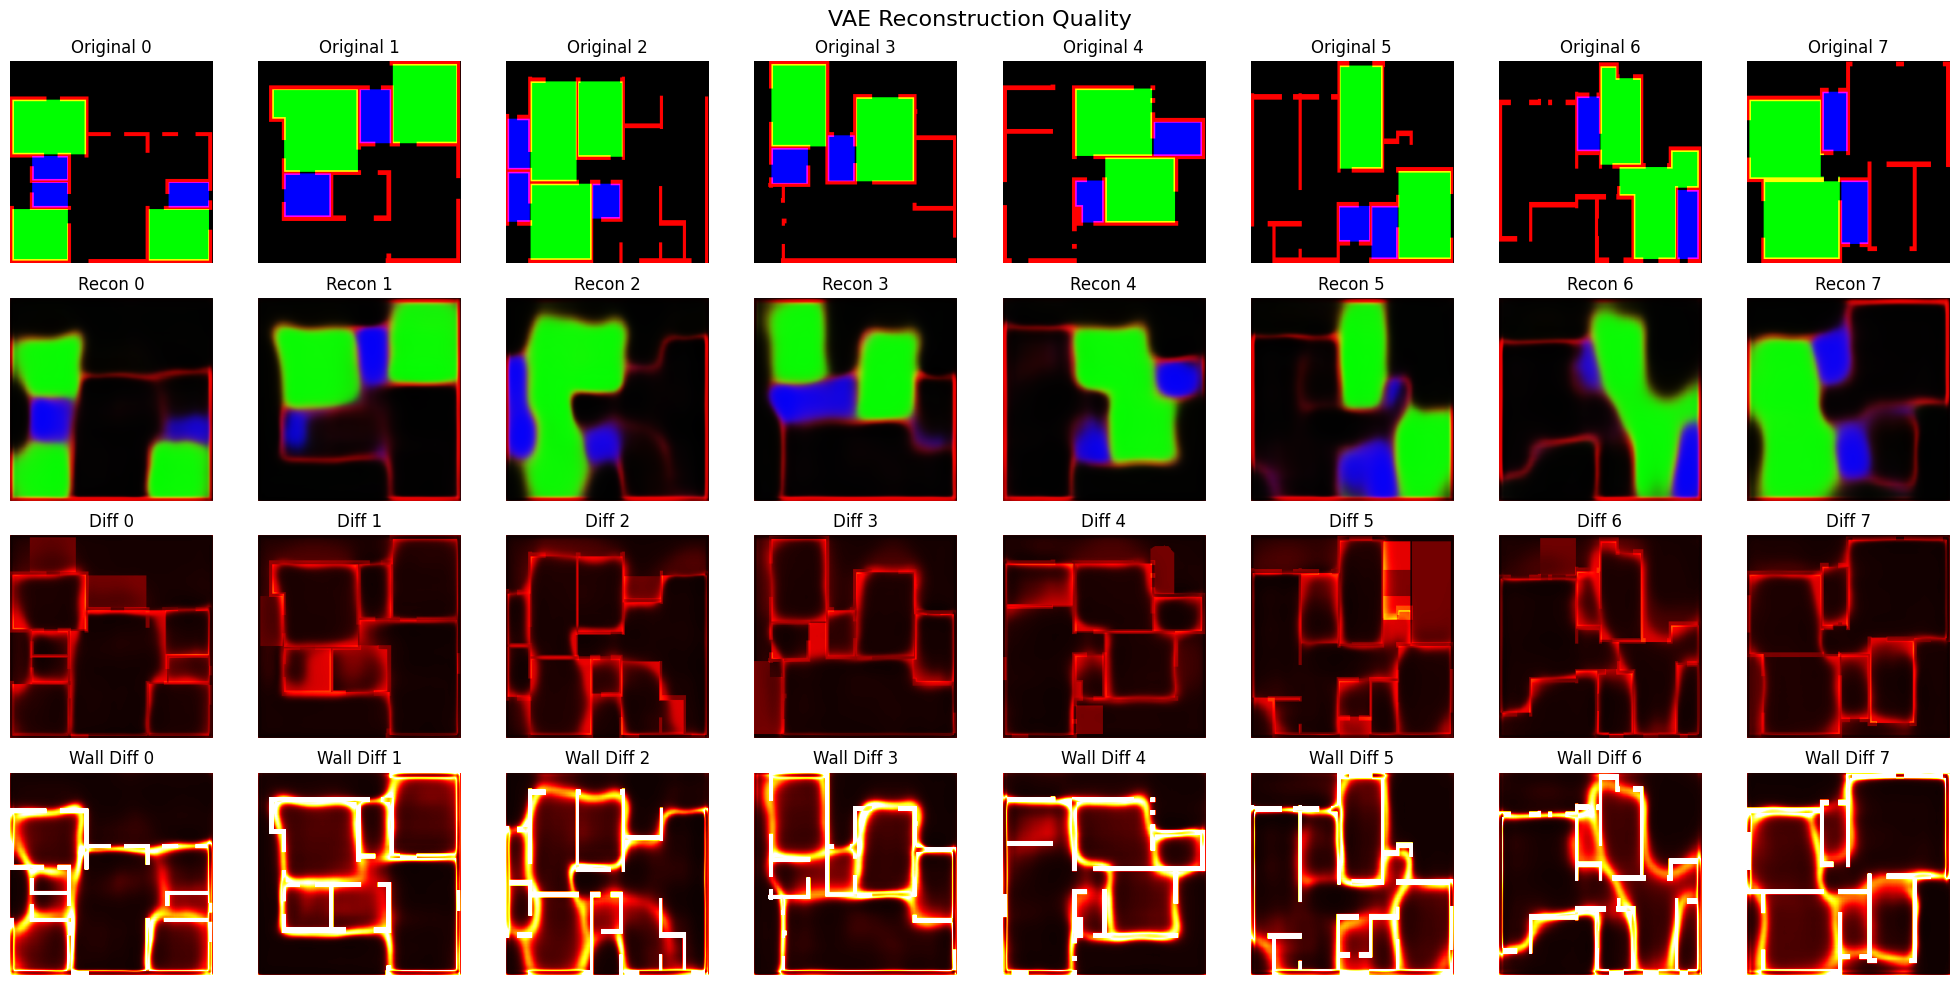

In [6]:
def compute_mse(pred, target):
    """Compute Mean Squared Error."""
    return F.mse_loss(pred, target, reduction='mean').item()


def compute_psnr(mse):
    """Compute Peak Signal-to-Noise Ratio."""
    if mse < 1e-10:
        return 100.0
    # For range [-1, 1], max pixel value = 2
    return 10 * np.log10(4.0 / mse)


def compute_metrics(vae, dataloader):
    """Compute comprehensive reconstruction metrics."""
    mse_list = []
    psnr_list = []
    per_channel_mse = defaultdict(list)
    
    vae.eval()
    with torch.no_grad():
        for images in tqdm(dataloader, desc="Computing metrics"):
            images = images.to(DEVICE)
            recon, mu, logvar = vae(images)
            
            # Overall MSE
            mse = compute_mse(recon, images)
            mse_list.append(mse)
            psnr_list.append(compute_psnr(mse))
            
            # Per-channel MSE
            for c in range(NUM_CHANNELS):
                channel_mse = compute_mse(recon[:, c], images[:, c])
                per_channel_mse[c].append(channel_mse)
    
    # Aggregate results
    results = {
        'mse': np.mean(mse_list),
        'psnr': np.mean(psnr_list),
        'per_channel_mse': {
            ROOM_TYPES[c]: np.mean(mses) 
            for c, mses in per_channel_mse.items()
        }
    }
    
    return results


print("\n" + "="*60)
print("COMPUTING RECONSTRUCTION METRICS")
print("="*60)

metrics = compute_metrics(vae, val_loader)

print(f"\nOverall MSE: {metrics['mse']:.6f}")
print(f"Overall PSNR: {metrics['psnr']:.2f} dB")

print("\nPer-Channel MSE:")
for room_type in ROOM_TYPES:
    mse = metrics['per_channel_mse'][room_type]
    print(f"  {room_type:12s}: {mse:.6f}")

# %% [markdown]
# # 7. Visual Quality Assessment

# %%
print("\n" + "="*60)
print("VISUAL QUALITY ASSESSMENT")
print("="*60)

# Get sample batch
sample_images = next(iter(val_loader))[:8].to(DEVICE)

# Generate reconstructions
with torch.no_grad():
    recon, mu, logvar = vae(sample_images)

# Visualize reconstructions
fig, axes = plt.subplots(4, 8, figsize=(20, 10))

for i in range(8):
    # Original
    orig = sample_images[i].cpu().numpy()
    orig = (orig + 1) / 2  # [-1, 1] -> [0, 1]
    
    # Create RGB from first 3 channels
    rgb_orig = np.transpose(orig[:3], (1, 2, 0))
    rgb_orig = np.clip(rgb_orig, 0, 1)
    
    axes[0, i].imshow(rgb_orig)
    axes[0, i].set_title(f'Original {i}')
    axes[0, i].axis('off')
    
    # Reconstructed
    rec = recon[i].cpu().numpy()
    rec = (rec + 1) / 2
    
    rgb_rec = np.transpose(rec[:3], (1, 2, 0))
    rgb_rec = np.clip(rgb_rec, 0, 1)
    
    axes[1, i].imshow(rgb_rec)
    axes[1, i].set_title(f'Recon {i}')
    axes[1, i].axis('off')
    
    # Difference map (absolute difference)
    diff = np.abs(orig - rec).mean(axis=0)
    axes[2, i].imshow(diff, cmap='hot', vmin=0, vmax=0.5)
    axes[2, i].set_title(f'Diff {i}')
    axes[2, i].axis('off')
    
    # Wall channel comparison
    axes[3, i].imshow(np.abs(orig[0] - rec[0]), cmap='hot', vmin=0, vmax=0.5)
    axes[3, i].set_title(f'Wall Diff {i}')
    axes[3, i].axis('off')

plt.suptitle('VAE Reconstruction Quality', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'reconstruction_quality.png'), dpi=150)
plt.show()


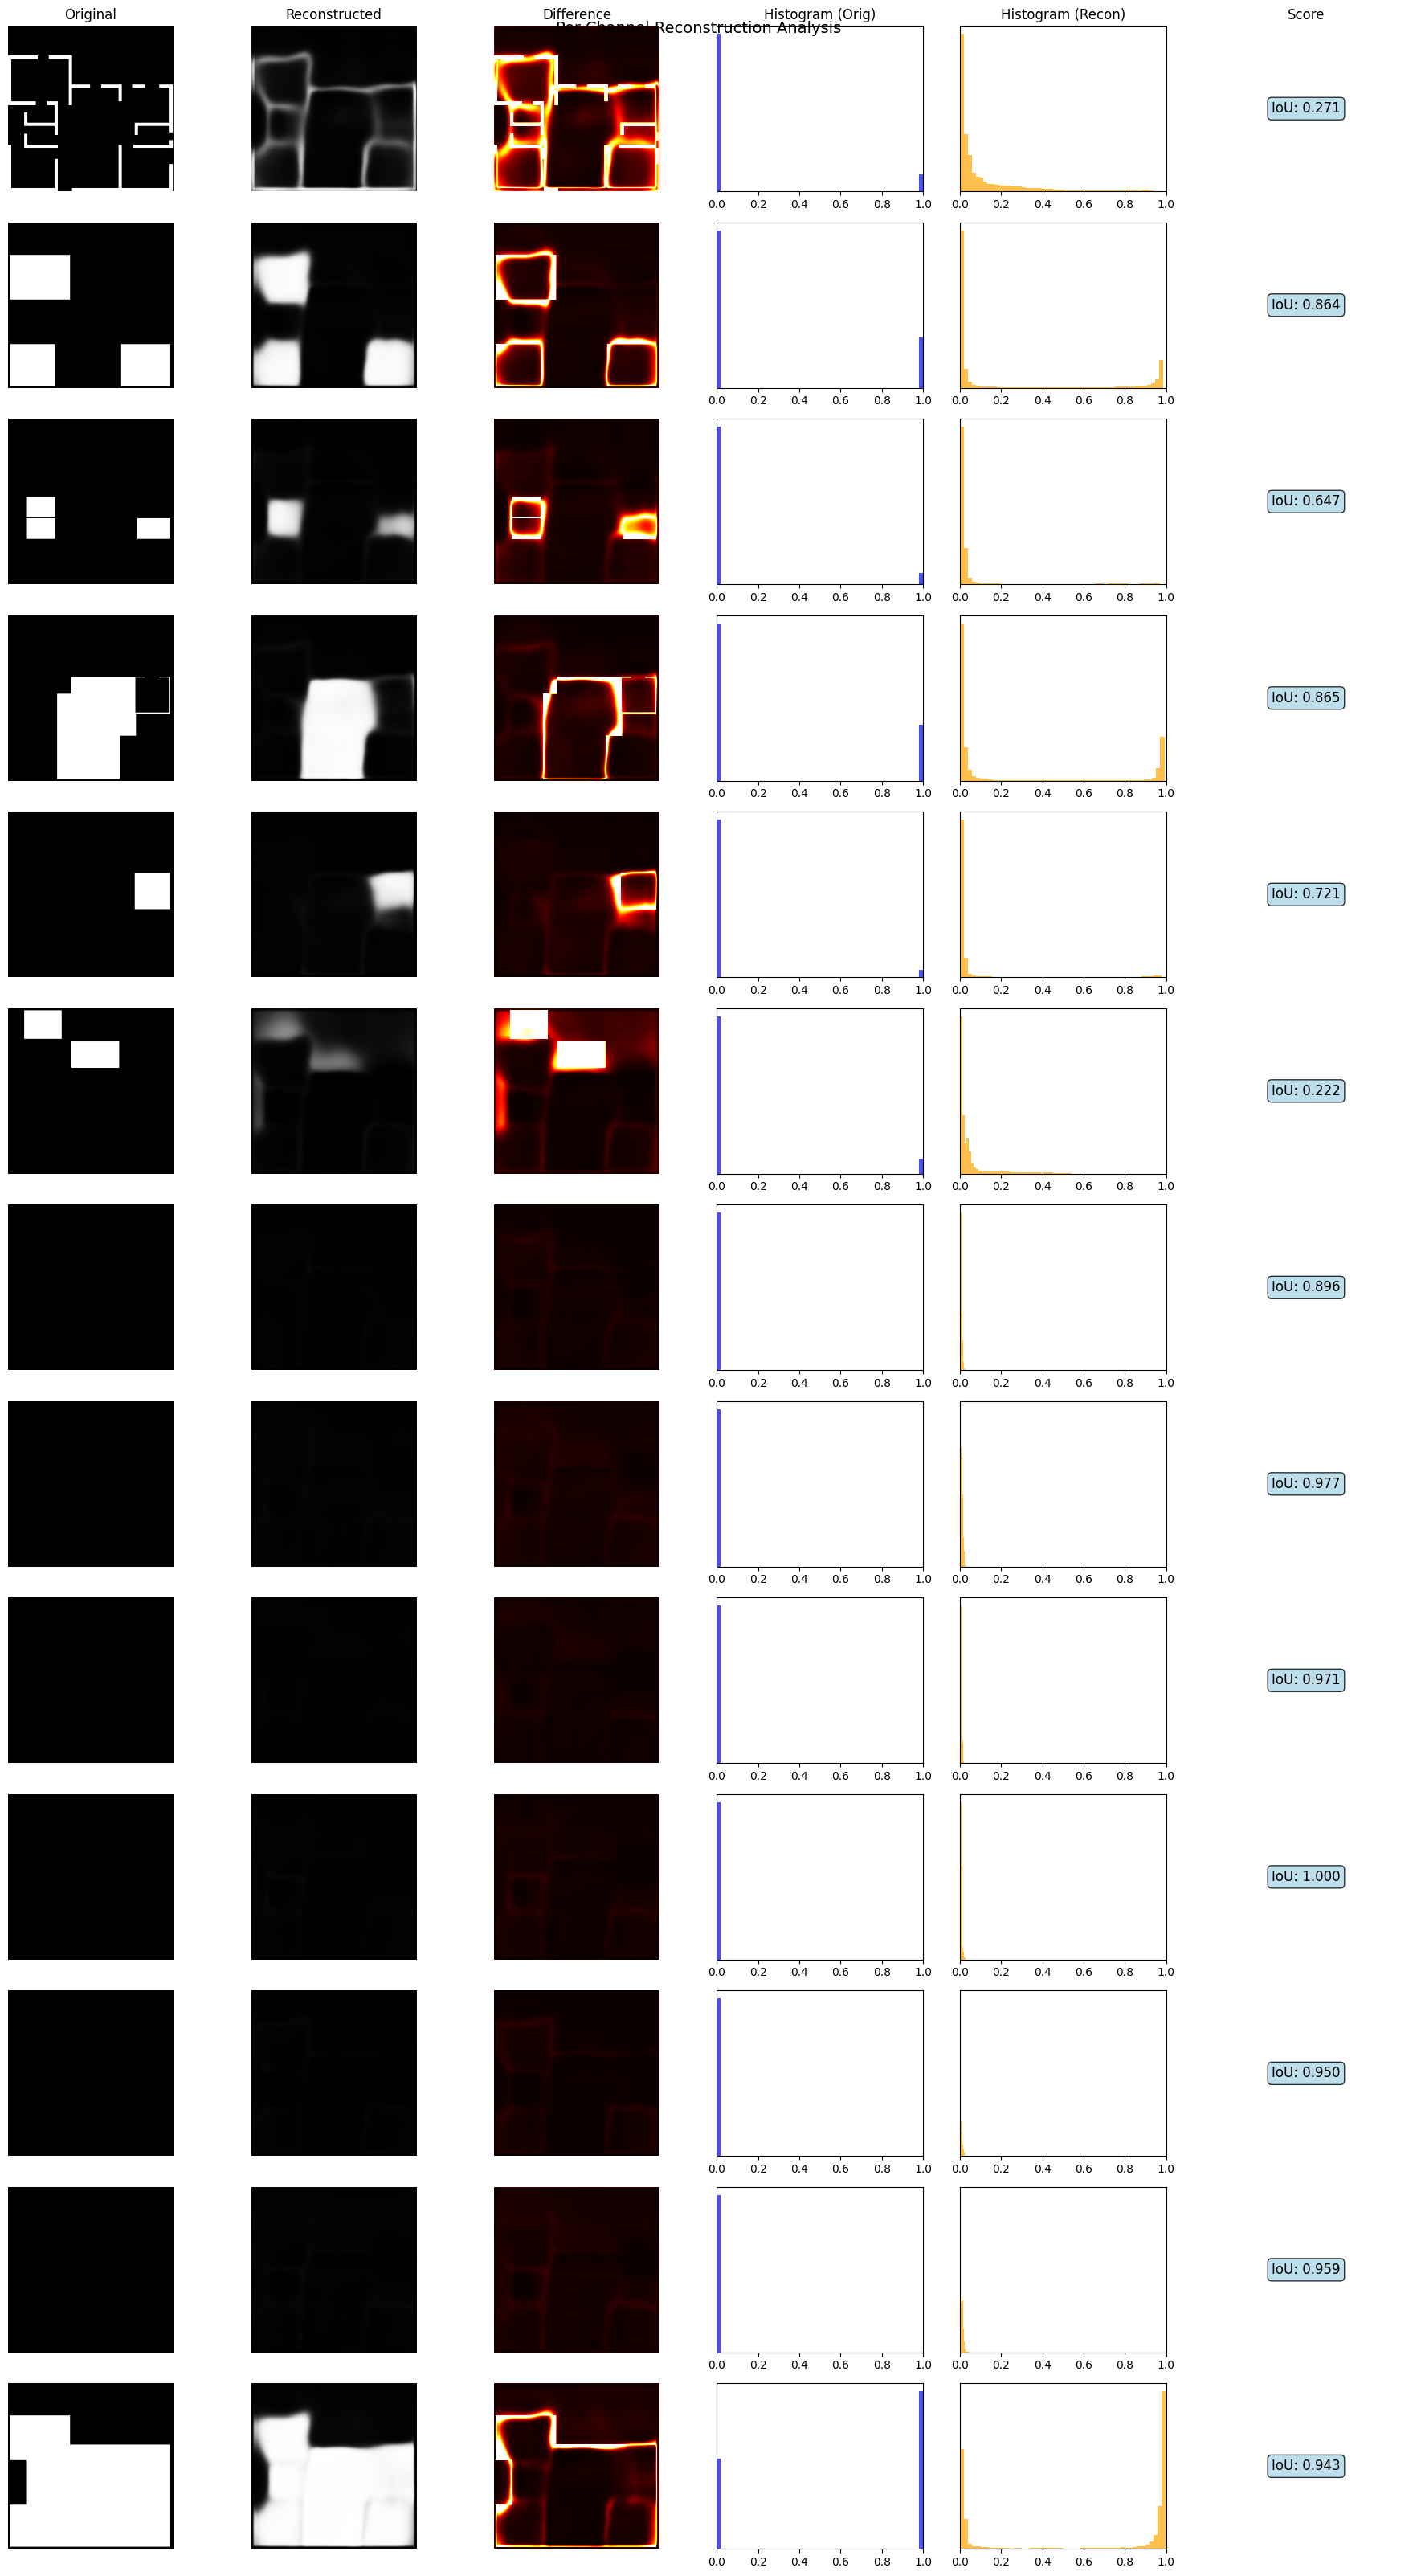

In [7]:
fig, axes = plt.subplots(NUM_CHANNELS, 6, figsize=(18, NUM_CHANNELS * 2.5))

sample_img = sample_images[0].cpu().numpy()
sample_recon = recon[0].cpu().numpy()

# Normalize
sample_img = (sample_img + 1) / 2
sample_recon = (sample_recon + 1) / 2

for c, room_type in enumerate(ROOM_TYPES):
    # Original
    axes[c, 0].imshow(sample_img[c], cmap='gray', vmin=0, vmax=1)
    axes[c, 0].set_ylabel(room_type, fontsize=10)
    if c == 0:
        axes[c, 0].set_title('Original')
    axes[c, 0].axis('off')
    
    # Reconstructed
    axes[c, 1].imshow(sample_recon[c], cmap='gray', vmin=0, vmax=1)
    if c == 0:
        axes[c, 1].set_title('Reconstructed')
    axes[c, 1].axis('off')
    
    # Difference
    diff = np.abs(sample_img[c] - sample_recon[c])
    axes[c, 2].imshow(diff, cmap='hot', vmin=0, vmax=0.5)
    if c == 0:
        axes[c, 2].set_title('Difference')
    axes[c, 2].axis('off')
    
    # Histogram of original
    axes[c, 3].hist(sample_img[c].flatten(), bins=50, alpha=0.7, color='blue')
    axes[c, 3].set_xlim([0, 1])
    if c == 0:
        axes[c, 3].set_title('Histogram (Orig)')
    axes[c, 3].set_yticks([])
    
    # Histogram of reconstruction
    axes[c, 4].hist(sample_recon[c].flatten(), bins=50, alpha=0.7, color='orange')
    axes[c, 4].set_xlim([0, 1])
    if c == 0:
        axes[c, 4].set_title('Histogram (Recon)')
    axes[c, 4].set_yticks([])
    
    # IoU score
    iou = mean_ious[room_type]
    axes[c, 5].text(0.5, 0.5, f'IoU: {iou:.3f}', 
                    ha='center', va='center', fontsize=12,
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    axes[c, 5].axis('off')
    if c == 0:
        axes[c, 5].set_title('Score')

plt.suptitle('Per-Channel Reconstruction Analysis', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'per_channel_analysis.png'), dpi=150)
plt.show()



LATENT SPACE ANALYSIS


Encoding: 100%|██████████| 63/63 [08:31<00:00,  8.12s/it]


Encoded 1000 samples

Latent statistics (μ):
  Mean: -0.0905
  Std: 2.6203
  Min: -12.4041
  Max: 14.5562

Latent statistics (log σ²):
  Mean: -4.9235
  Std: 1.3215

Active latent dimensions (std > 0.01): 256/256
  ✓ Most dimensions active - good latent space


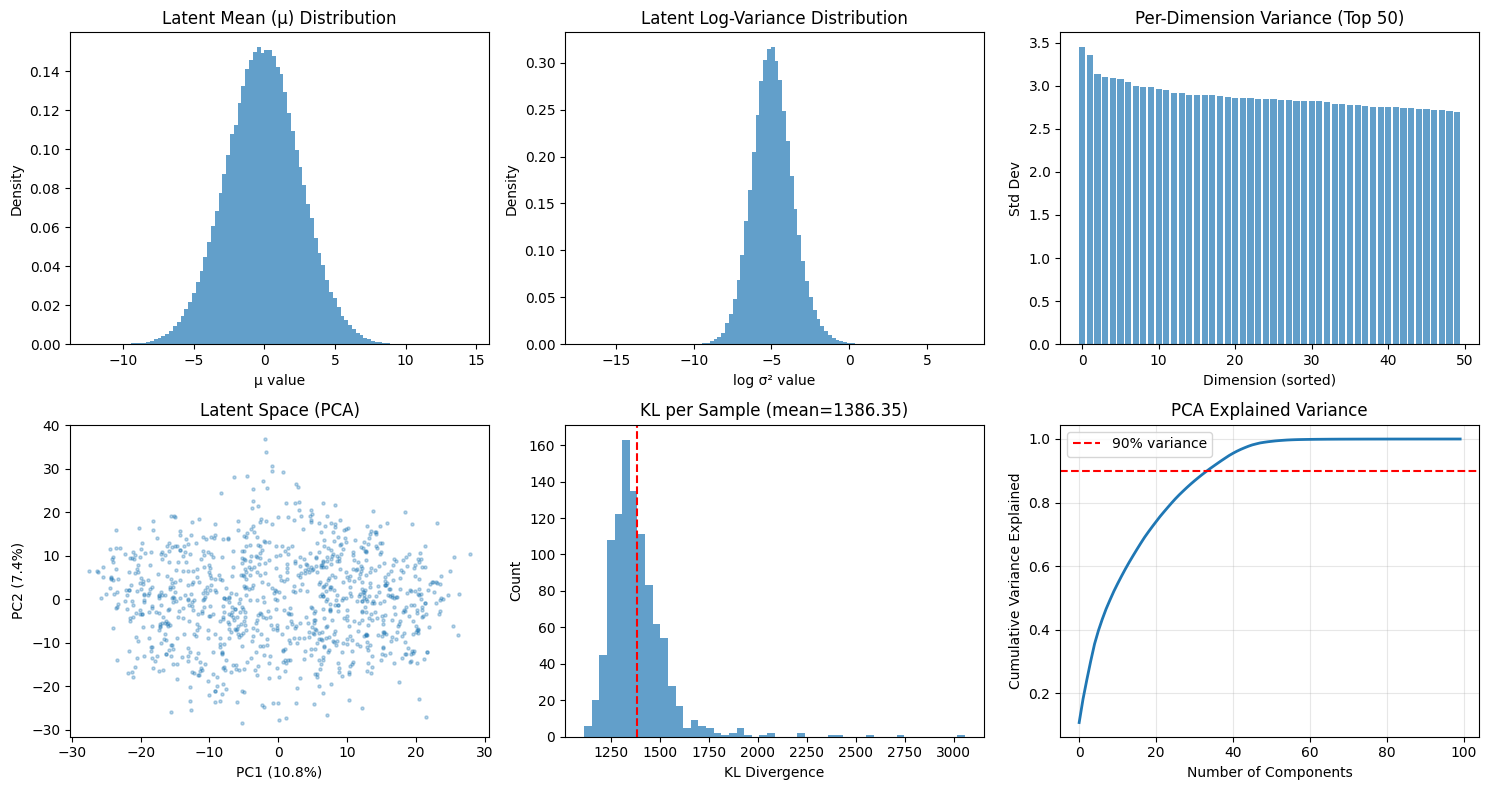

In [8]:
print("\n" + "="*60)
print("LATENT SPACE ANALYSIS")
print("="*60)

# Encode all validation samples
all_mus = []
all_logvars = []

vae.eval()
with torch.no_grad():
    for images in tqdm(val_loader, desc="Encoding"):
        images = images.to(DEVICE)
        mu, logvar = vae.encoder(images)
        all_mus.append(mu.cpu().numpy())
        all_logvars.append(logvar.cpu().numpy())

all_mus = np.concatenate(all_mus, axis=0)
all_logvars = np.concatenate(all_logvars, axis=0)

print(f"Encoded {len(all_mus)} samples")

# Statistics
print(f"\nLatent statistics (μ):")
print(f"  Mean: {all_mus.mean():.4f}")
print(f"  Std: {all_mus.std():.4f}")
print(f"  Min: {all_mus.min():.4f}")
print(f"  Max: {all_mus.max():.4f}")

print(f"\nLatent statistics (log σ²):")
print(f"  Mean: {all_logvars.mean():.4f}")
print(f"  Std: {all_logvars.std():.4f}")

# Check for latent collapse
active_dims = (all_mus.std(axis=0) > 0.01).sum()
print(f"\nActive latent dimensions (std > 0.01): {active_dims}/{LATENT_DIM}")

if active_dims < LATENT_DIM * 0.5:
    print("  ⚠️ WARNING: Many inactive dimensions - possible partial collapse")
elif active_dims < LATENT_DIM * 0.8:
    print("  ○ Some inactive dimensions - acceptable")
else:
    print("  ✓ Most dimensions active - good latent space")

# Visualize latent distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# μ distribution
ax = axes[0, 0]
ax.hist(all_mus.flatten(), bins=100, density=True, alpha=0.7)
ax.set_xlabel('μ value')
ax.set_ylabel('Density')
ax.set_title('Latent Mean (μ) Distribution')

# log σ² distribution
ax = axes[0, 1]
ax.hist(all_logvars.flatten(), bins=100, density=True, alpha=0.7)
ax.set_xlabel('log σ² value')
ax.set_ylabel('Density')
ax.set_title('Latent Log-Variance Distribution')

# Per-dimension std
ax = axes[0, 2]
dim_stds = all_mus.std(axis=0)
ax.bar(range(min(50, len(dim_stds))), sorted(dim_stds, reverse=True)[:50], alpha=0.7)
ax.set_xlabel('Dimension (sorted)')
ax.set_ylabel('Std Dev')
ax.set_title('Per-Dimension Variance (Top 50)')

# PCA visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
latents_2d = pca.fit_transform(all_mus)

ax = axes[1, 0]
ax.scatter(latents_2d[:, 0], latents_2d[:, 1], alpha=0.3, s=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Latent Space (PCA)')

# KL divergence per sample
kl_per_sample = -0.5 * (1 + all_logvars - all_mus**2 - np.exp(all_logvars)).sum(axis=1)

ax = axes[1, 1]
ax.hist(kl_per_sample, bins=50, alpha=0.7)
ax.set_xlabel('KL Divergence')
ax.set_ylabel('Count')
ax.set_title(f'KL per Sample (mean={kl_per_sample.mean():.2f})')
ax.axvline(kl_per_sample.mean(), color='r', linestyle='--')

# Variance explained by PCA
pca_full = PCA()
pca_full.fit(all_mus)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

ax = axes[1, 2]
ax.plot(cumsum[:100], linewidth=2)
ax.axhline(y=0.9, color='r', linestyle='--', label='90% variance')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance Explained')
ax.set_title('PCA Explained Variance')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'latent_space_analysis.png'), dpi=150)
plt.show()



RANDOM SAMPLING QUALITY


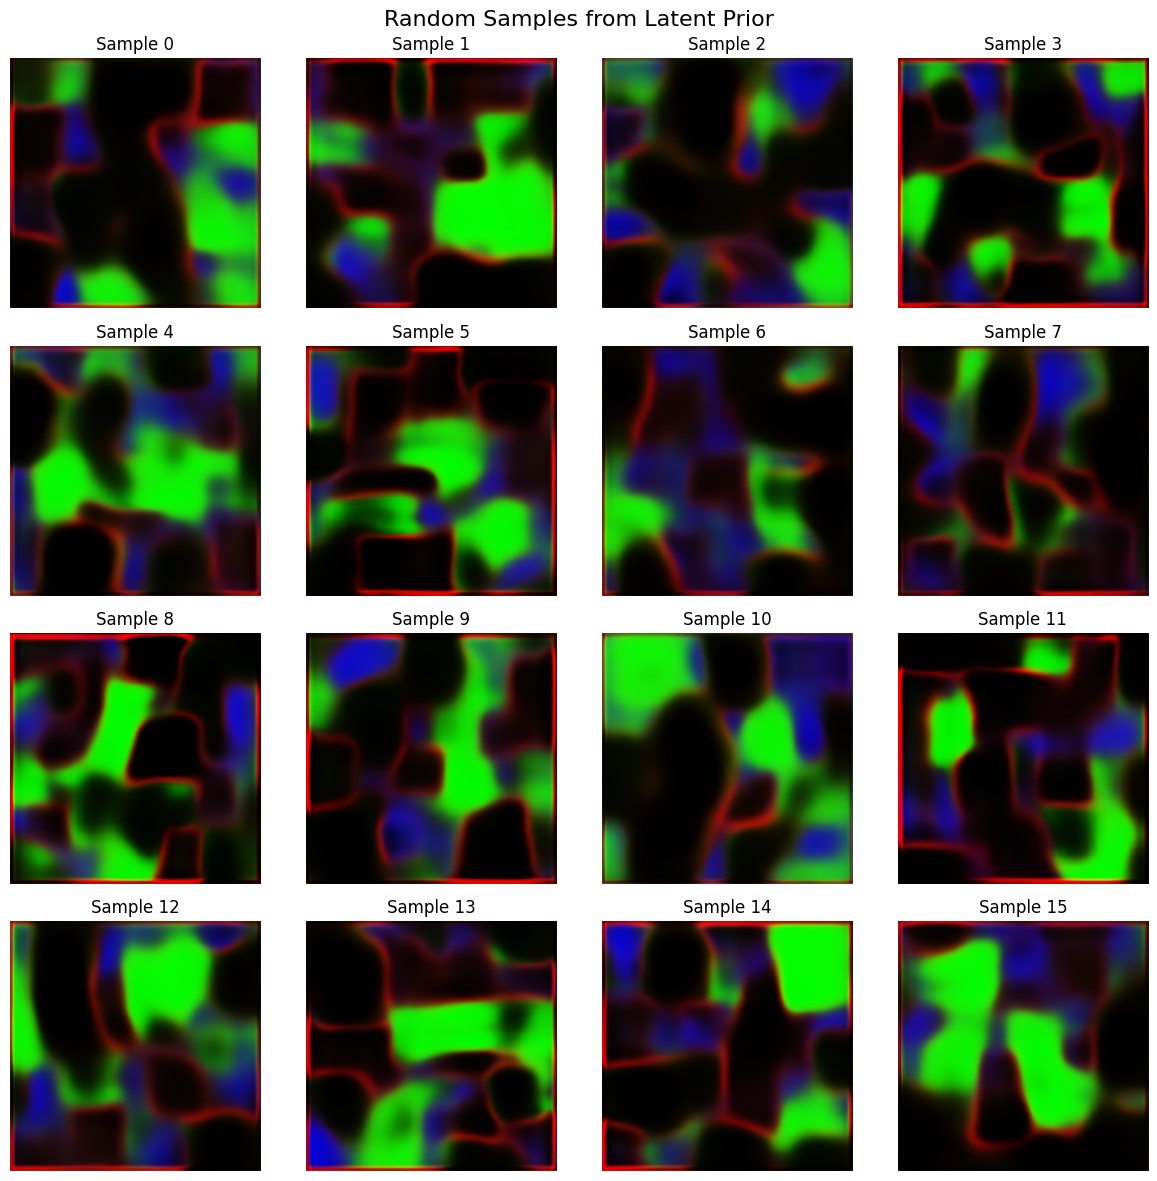

Average pixel coverage: 17.4%
  ✓ Sample quality looks reasonable


In [9]:
print("\n" + "="*60)
print("RANDOM SAMPLING QUALITY")
print("="*60)

# Sample from prior N(0, I)
num_samples = 16
z_samples = torch.randn(num_samples, LATENT_DIM).to(DEVICE)

with torch.no_grad():
    generated = vae.decode(z_samples)

# Visualize
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i in range(16):
    ax = axes[i // 4, i % 4]
    
    img = generated[i].cpu().numpy()
    img = (img + 1) / 2  # [-1, 1] -> [0, 1]
    
    # RGB from first 3 channels
    rgb = np.transpose(img[:3], (1, 2, 0))
    rgb = np.clip(rgb, 0, 1)
    
    ax.imshow(rgb)
    ax.set_title(f'Sample {i}')
    ax.axis('off')

plt.suptitle('Random Samples from Latent Prior', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'random_samples.png'), dpi=150)
plt.show()

# Check sample quality
sample_quality = []
for i in range(num_samples):
    img = generated[i].cpu().numpy()
    img = (img + 1) / 2
    
    # Check if not empty
    coverage = (img > 0.1).mean()
    sample_quality.append(coverage)

print(f"Average pixel coverage: {np.mean(sample_quality)*100:.1f}%")
if np.mean(sample_quality) < 0.05:
    print("  ⚠️ Samples mostly empty - possible latent collapse or poor decoder")
elif np.mean(sample_quality) > 0.8:
    print("  ⚠️ Samples too saturated - possible mode collapse")
else:
    print("  ✓ Sample quality looks reasonable")

In [10]:
print("\n" + "="*60)
print("VAE VALIDATION SUMMARY REPORT")
print("="*60)

print("\n📊 RECONSTRUCTION METRICS\n")
print(f"Overall Mean IoU: {overall_iou:.4f}")
print(f"Overall MSE: {metrics['mse']:.6f}")
print(f"Overall PSNR: {metrics['psnr']:.2f} dB")

print("\n📋 TOP 5 CHANNELS BY IoU\n")
top_5 = sorted(mean_ious.items(), key=lambda x: -x[1])[:5]
for room, iou in top_5:
    print(f"  {room:12s}: {iou:.4f}")

print("\n📋 BOTTOM 5 CHANNELS BY IoU\n")
bottom_5 = sorted(mean_ious.items(), key=lambda x: x[1])[:5]
for room, iou in bottom_5:
    print(f"  {room:12s}: {iou:.4f}")

print("\n🧠 LATENT SPACE QUALITY\n")
print(f"Active dimensions: {active_dims}/{LATENT_DIM} ({active_dims/LATENT_DIM*100:.1f}%)")
print(f"Mean KL divergence: {kl_per_sample.mean():.2f}")
print(f"Latent std: {all_mus.std():.4f}")

print("\n📈 QUALITY ASSESSMENT\n")

# Overall assessment
if overall_iou > 0.7:
    print("✓ Reconstruction quality: Excellent")
elif overall_iou > 0.5:
    print("○ Reconstruction quality: Good")
elif overall_iou > 0.3:
    print("○ Reconstruction quality: Moderate")
else:
    print("✗ Reconstruction quality: Poor - model needs more training")

if kl_per_sample.mean() > 10:
    print("⚠️ KL divergence high - latent space may be over-constrained")
elif kl_per_sample.mean() < 0.1:
    print("⚠️ KL divergence very low - possible posterior collapse")
else:
    print("✓ KL divergence in healthy range")

if active_dims > LATENT_DIM * 0.8:
    print("✓ Latent space well-utilized")
elif active_dims > LATENT_DIM * 0.5:
    print("○ Latent space moderately utilized")
else:
    print("✗ Many inactive dimensions - possible collapse")

# Save detailed report
report_file = os.path.join(OUTPUT_PATH, 'validation_report.txt')
with open(report_file, 'w') as f:
    f.write("VAE VALIDATION REPORT\n")
    f.write("="*50 + "\n\n")
    
    f.write("CHECKPOINT INFO\n")
    f.write(f"Epoch: {checkpoint['epoch']}\n")
    f.write(f"Val loss: {checkpoint.get('val_loss', 'N/A')}\n\n")
    
    f.write("RECONSTRUCTION METRICS\n")
    f.write(f"Overall IoU: {overall_iou:.4f}\n")
    f.write(f"Overall MSE: {metrics['mse']:.6f}\n")
    f.write(f"Overall PSNR: {metrics['psnr']:.2f} dB\n\n")
    
    f.write("PER-CHANNEL IoU\n")
    for room_type in ROOM_TYPES:
        f.write(f"  {room_type:12s}: {mean_ious[room_type]:.4f}\n")
    f.write("\n")
    
    f.write("LATENT SPACE\n")
    f.write(f"Active dimensions: {active_dims}/{LATENT_DIM}\n")
    f.write(f"Mean KL: {kl_per_sample.mean():.2f}\n")
    f.write(f"Latent mean std: {all_mus.std():.4f}\n")

print(f"\n📄 Detailed report saved to: {report_file}")

print("\n📁 OUTPUT FILES\n")
output_files = sorted([f for f in os.listdir(OUTPUT_PATH) if os.path.isfile(os.path.join(OUTPUT_PATH, f))])
for f in output_files:
    size = os.path.getsize(os.path.join(OUTPUT_PATH, f)) / 1e6
    print(f"  {f}: {size:.1f} MB")

print("\n" + "="*60)
print("VALIDATION COMPLETE")
print("="*60)

# Clean up
del vae, all_mus, all_logvars
gc.collect()
torch.cuda.empty_cache()



VAE VALIDATION SUMMARY REPORT

📊 RECONSTRUCTION METRICS

Overall Mean IoU: 0.7912
Overall MSE: 0.070547
Overall PSNR: 17.56 dB

📋 TOP 5 CHANNELS BY IoU

  pool        : 1.0000
  parking     : 0.9770
  garden      : 0.9710
  veranda     : 0.9590
  stair       : 0.9500

📋 BOTTOM 5 CHANNELS BY IoU

  balcony     : 0.2221
  wall        : 0.2708
  bathroom    : 0.6470
  kitchen     : 0.7215
  bedroom     : 0.8636

🧠 LATENT SPACE QUALITY

Active dimensions: 256/256 (100.0%)
Mean KL divergence: 1386.35
Latent std: 2.6203

📈 QUALITY ASSESSMENT

✓ Reconstruction quality: Excellent
⚠️ KL divergence high - latent space may be over-constrained
✓ Latent space well-utilized

📄 Detailed report saved to: /kaggle/working/vae_validation/validation_report.txt

📁 OUTPUT FILES

  iou_per_channel.png: 0.1 MB
  latent_space_analysis.png: 0.2 MB
  per_channel_analysis.png: 0.7 MB
  random_samples.png: 1.7 MB
  reconstruction_quality.png: 1.1 MB
  validation_report.txt: 0.0 MB

VALIDATION COMPLETE
